In [24]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from scipy.io import loadmat

In [25]:
def to_records(mat_path):
    mat = loadmat(mat_path, squeeze_me=True, simplify_cells=True)
    data = mat["data"]
    # Si ya te sale como lista de dicts, devuelve eso:
    if isinstance(data, list) and len(data) and isinstance(data[0], dict):
        return data

    # Si te sale como array estructurado con nombres:
    if isinstance(data, np.ndarray) and data.dtype.names:
        recs = []
        for i in range(data.shape[0]):
            rec = {k: data[k][i] for k in data.dtype.names}
            recs.append(rec)
        return recs

    # Fallback: si viene como 1 x N de tuplas, no adivino nombres aquí
    raise ValueError("No pude convertir 'data' a records con nombres; imprime type(data), data.dtype, data.dtype.names")

def records_to_df(records):
    # normaliza trialErrors (string/dict)
    def norm_err(v):
        if v is None: return {}
        if isinstance(v, dict): return v
        if isinstance(v, str) and v.lower() == "none": return {}
        return {"trialErrors_raw": v}

    recs = []
    for r in records:
        r = dict(r)
        r["trialErrors"] = norm_err(r.get("trialErrors"))
        recs.append(r)

    return pd.json_normalize(recs, sep="_")

def load_monkey(monkey_name):
    root = Path("/Users/tomroper/Documents/Leaving Variability/Patch") / monkey_name
    mats = sorted(root.rglob("*.mat"))

    rows = []
    # ejemplo Calvin: C130326.2.C.mat  => date=C130326, session=2
    calvin_pat = re.compile(r"^(C\d{6})\.(\d+)\.C\.mat$")

    for p in mats:
        records = to_records(str(p))
        df = records_to_df(records)

        df["monkey"] = monkey_name
        df["file"] = str(p)

        m = calvin_pat.match(p.name)
        if m:
            df["date"] = m.group(1)
            df["session"] = int(m.group(2))
        else:
            # para otros esquemas (ernie/oscar), guarda al menos el nombre del archivo
            df["date"] = p.parent.name
            df["session"] = pd.NA

        rows.append(df)

    df_all = pd.concat(rows, ignore_index=True)

    # opcional: id único global del trial dentro de (monkey,date,session)
    if "trial" in df_all.columns:
        df_all["trial"] = pd.to_numeric(df_all["trial"], errors="coerce")
        df_all["trial_uid"] = (
            df_all["monkey"].astype(str) + "|" +
            df_all["date"].astype(str) + "|" +
            df_all["session"].astype(str) + "|" +
            df_all["trial"].astype(int).astype(str)
        )

    return df_all

df = load_monkey("calvin")   # o "ernie", "oscar"

In [18]:
mat = loadmat(file_path, squeeze_me=True, simplify_cells=True)
data = mat["data"]

In [20]:
records = data

# 1) Normalize trialErrors so it is always a dict (easy to flatten)
def normalize_trial_errors(v):
    if v is None:
        return {}
    if isinstance(v, dict):
        return v
    if isinstance(v, str) and v.lower() == "none":
        return {}
    return {"trialErrors_raw": v}

records2 = []
for r in records:
    r = dict(r)
    r["trialErrors"] = normalize_trial_errors(r.get("trialErrors"))
    records2.append(r)

# 2) Flatten to a DataFrame; trialErrors fields become columns like trialErrors_error1
df = pd.json_normalize(records2, sep="_")

# 3) Optional: clean common fields
df["rewarded"] = df["rewarded"].map({"yes": True, "no": False}).astype("boolean")
df["choiceMade"] = df["choiceMade"].astype("category")
df["stayBarOn"] = df["stayBarOn"].astype("category")

df.head()

,trial,stayBarOn,foragingTime,choiceMade,rewarded,rewardSize,timeToFixate,minFixTimeToStart,holdFixTime,timeToChoose,ITI,timeInErrorState,allForagingTimes,shrinkRate,handlingTime,allJuiceAmounts,choiceTime,completeTime,trialErrors_error1,trialErrors_error2
0,1,right,2,stay,True,0.200,30,0.05,0.1,2147483647,1,3,2,65,0.4,"[0.2, 0.187, 0.174, 0.16099999999999998, 0.147...",0.414781,0.414789,NaN,NaN
1,2,right,2,stay,True,0.187,30,0.05,0.1,2147483647,1,3,2,65,0.4,"[0.2, 0.187, 0.174, 0.16099999999999998, 0.147...",0.414807,0.414814,NaN,NaN
2,3,right,2,stay,True,0.174,30,0.05,0.1,2147483647,1,3,2,65,0.4,"[0.2, 0.187, 0.174, 0.16099999999999998, 0.147...",0.414833,0.414840,NaN,NaN
3,4,right,2,leave,False,0.000,30,0.05,0.1,2147483647,1,3,2,65,0.4,"[0.2, 0.187, 0.174, 0.16099999999999998, 0.147...",0.414859,0.414896,NaN,NaN
4,5,left,2,stay,True,0.200,30,0.05,0.1,2147483647,1,3,2,65,0.4,"[0.2, 0.187, 0.174, 0.16099999999999998, 0.147...",0.414913,0.414920,NaN,NaN


count    2470.000000
mean        6.838866
std         6.350626
min         1.000000
25%         2.000000
50%         5.000000
75%         9.000000
max        43.000000
dtype: float64


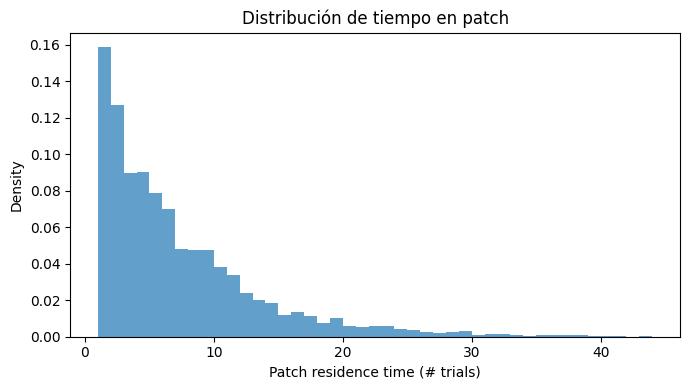

In [26]:
# Asegura orden temporal
df = df.sort_values("trial").reset_index(drop=True)

# patch_id: cada vez que hubo un "leave", el SIGUIENTE trial empieza un patch nuevo
df["patch_id"] = df["choiceMade"].eq("leave").shift(fill_value=False).cumsum()

# Tamaño del patch en #trials (incluye el trial donde eliges "leave")
patch_n_trials = df.groupby("patch_id").size()

# Alternativas (por si las quieres):
# - #stays antes de salir (no incluye el "leave")
patch_n_stays = df.groupby("patch_id")["choiceMade"].apply(lambda s: (s == "stay").sum())
# - indicador de si el patch terminó con leave (normalmente True salvo el último si quedó incompleto)
patch_has_leave = df.groupby("patch_id")["choiceMade"].apply(lambda s: (s == "leave").any())

# Qué usar como "patch time" (elige 1):
patch_time = patch_n_trials[patch_has_leave]   # patches completos, en #trials
# patch_time = patch_n_stays[patch_has_leave]  # patches completos, en #stays

print(patch_time.describe())

plt.figure(figsize=(7,4))
plt.hist(patch_time, bins=range(int(patch_time.min()), int(patch_time.max()) + 2), density=True, alpha=0.7)
plt.xlabel("Patch residence time (# trials)")
plt.ylabel("Density")
plt.title("Distribución de tiempo en patch")
plt.tight_layout()
plt.show()

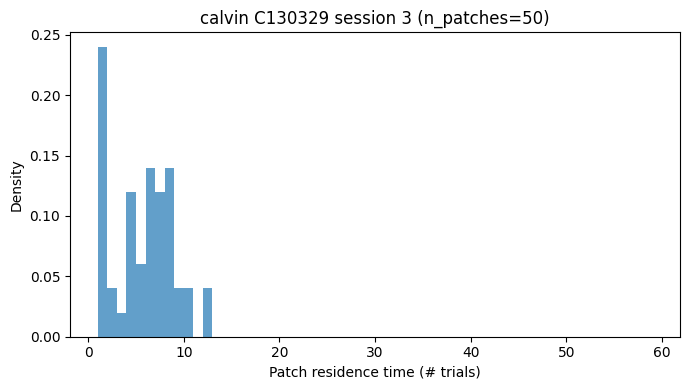

In [40]:
import matplotlib.pyplot as plt

def patch_lengths_for_session(df, monkey, date, session, count="trials"):
    d = df.query("monkey == @monkey and date == @date and session == @session").copy()
    d = d.sort_values("trial")

    d["patch_id"] = d["choiceMade"].eq("leave").shift(fill_value=False).cumsum()

    g = d.groupby("patch_id")["choiceMade"]
    has_leave = g.apply(lambda s: (s == "leave").any())

    if count == "trials":      # incluye el trial de "leave"
        lengths = d.groupby("patch_id").size()
    elif count == "stays":     # solo cuenta "stay"
        lengths = g.apply(lambda s: (s == "stay").sum())
    else:
        raise ValueError("count must be 'trials' or 'stays'")

    return lengths[has_leave]  # solo patches completos

def plot_patch_dist_one_session(df, monkey, date, session, count="trials", bins="auto"):
    lengths = patch_lengths_for_session(df, monkey, date, session, count=count)

    plt.figure(figsize=(7,4))
    plt.hist(lengths, bins=bins, density=True, alpha=0.7)
    plt.xlabel(f"Patch residence time (# {count})")
    plt.ylabel("Density")
    plt.title(f"{monkey} {date} session {session} (n_patches={len(lengths)})")
    plt.tight_layout()
    plt.show()

# ejemplo:
plot_patch_dist_one_session(df, monkey="calvin", date="C130329", session=3, count="trials", bins=range(1, 60))

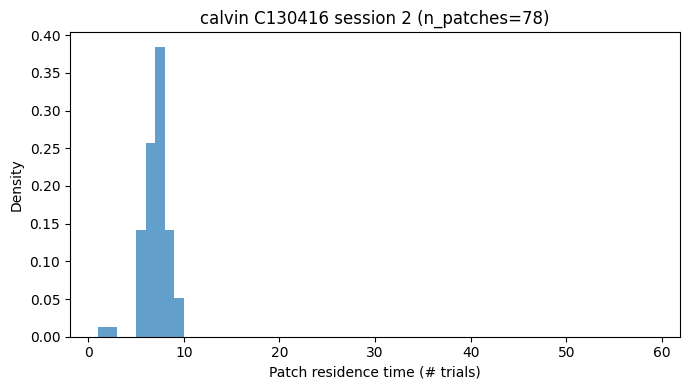

In [37]:
import matplotlib.pyplot as plt

def patch_lengths_for_session(df, monkey, date, session, count="trials"):
    d = df.query("monkey == @monkey and date == @date and session == @session").copy()
    d = d.sort_values("trial")

    d["patch_id"] = d["choiceMade"].eq("leave").shift(fill_value=False).cumsum()

    g = d.groupby("patch_id")["choiceMade"]
    has_leave = g.apply(lambda s: (s == "leave").any())

    if count == "trials":      # incluye el trial de "leave"
        lengths = d.groupby("patch_id").size()
    elif count == "stays":     # solo cuenta "stay"
        lengths = g.apply(lambda s: (s == "stay").sum())
    else:
        raise ValueError("count must be 'trials' or 'stays'")

    return lengths[has_leave]  # solo patches completos

def plot_patch_dist_one_session(df, monkey, date, session, count="trials", bins="auto"):
    lengths = patch_lengths_for_session(df, monkey, date, session, count=count)

    plt.figure(figsize=(7,4))
    plt.hist(lengths, bins=bins, density=True, alpha=0.7)
    plt.xlabel(f"Patch residence time (# {count})")
    plt.ylabel("Density")
    plt.title(f"{monkey} {date} session {session} (n_patches={len(lengths)})")
    plt.tight_layout()
    plt.show()

# ejemplo:
plot_patch_dist_one_session(df, monkey="calvin", date="C130416", session=2, count="trials", bins=range(1, 60))

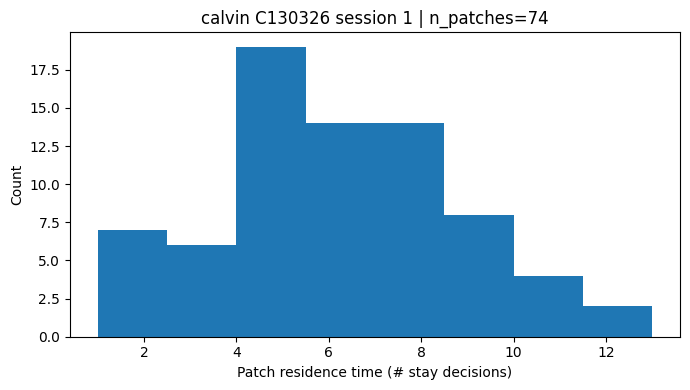

Session mean: 5.9324324324324325 std: 2.680886589606317
All mean: 6.897551224387806 std: 3.0548320740262875


In [43]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ---------- 1) Cargar un .mat (Calvin) y pasarlo a DataFrame ----------
def normalize_trial_errors(v):
    if v is None:
        return {}
    if isinstance(v, dict):
        return v
    if isinstance(v, str) and v.lower() == "none":
        return {}
    return {"trialErrors_raw": v}

def mat_to_records(mat_path):
    mat = loadmat(mat_path, squeeze_me=True, simplify_cells=True)
    data = mat["data"]

    # caso A: lista de dicts ya lista
    if isinstance(data, list) and len(data) and isinstance(data[0], dict):
        return data

    # caso B: array estructurado con nombres
    if isinstance(data, np.ndarray) and data.dtype.names:
        recs = []
        n = data.shape[0] if data.ndim else 1
        for i in range(n):
            rec = {k: data[k][i] if n > 1 else data[k] for k in data.dtype.names}
            recs.append(rec)
        return recs

    raise ValueError(f"No pude convertir 'data' a records: {mat_path}")

def records_to_df(records):
    recs = []
    for r in records:
        r = dict(r)
        r["trialErrors"] = normalize_trial_errors(r.get("trialErrors"))
        recs.append(r)
    return pd.json_normalize(recs, sep="_")

_calvin_pat = re.compile(r"^(C\d{6})\.(\d+)\.C\.mat$")

def load_calvin_all_sessions(monkey="calvin"):
    root = Path("/Users/tomroper/Documents/Leaving Variability/Patch") / monkey
    mats = sorted(root.rglob("*.mat"))

    dfs = []
    for p in mats:
        m = _calvin_pat.match(p.name)
        if not m:
            continue  # solo Calvin estilo CYYMMDD.#.C.mat

        date = m.group(1)
        session = int(m.group(2))

        df = records_to_df(mat_to_records(str(p)))
        df["monkey"] = monkey
        df["date"] = date
        df["session"] = session
        df["file"] = str(p)

        # tipos útiles
        if "trial" in df.columns:
            df["trial"] = pd.to_numeric(df["trial"], errors="coerce")

        dfs.append(df)

    if not dfs:
        raise ValueError(f"No encontré .mat para {monkey} en {root}")

    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

# ---------- 2) Patch length "como en el paper" ----------
# Definición paper: patch residence time = # "stay decisions" antes del "leave"
# y descarta patches con length < 1. También suele ignorar el último patch si no terminó en leave.
def patch_lengths_like_paper(df_sess, exclude_errors=False):
    d = df_sess.sort_values("trial").reset_index(drop=True).copy()

    if exclude_errors and "trialErrors" in d.columns:
        # trialErrors puede ser dict normalizado a columnas trialErrors_*,
        # pero si aún tienes trialErrors como string/dict, filtra lo obvio:
        if d["trialErrors"].dtype == object:
            d = d[d["trialErrors"].isin(["none", None, {}])].copy()

    is_leave = d["choiceMade"].eq("leave").to_numpy()
    leave_idx = np.flatnonzero(is_leave)  # índices donde ocurre leave
    if len(leave_idx) == 0:
        return pd.Series(dtype=int, name="patchLength")

    starts = np.r_[0, leave_idx[:-1] + 1]   # inicio de cada patch
    lengths = leave_idx - starts            # #stays antes del leave (NO incluye leave)
    lengths = pd.Series(lengths, name="patchLength")

    # como el MATLAB: goodPatches length >= 1
    lengths = lengths[lengths >= 1]
    return lengths

def trim_outliers_mean3std(x):
    if len(x) < 3:
        return x
    cutoff = x.mean() + 3 * x.std(ddof=1)
    return x[x < cutoff]

# ---------- 3) Plot: una sesión o todas las sesiones ----------
def plot_patch_dist_one_session(df_all, monkey, date, session, bins=8, cutoff_3std=True):
    d = df_all.query("monkey==@monkey and date==@date and session==@session")
    L = patch_lengths_like_paper(d)
    if cutoff_3std:
        L = trim_outliers_mean3std(L)

    plt.figure(figsize=(7,4))
    plt.hist(L, bins=bins)
    plt.xlabel("Patch residence time (# stay decisions)")
    plt.ylabel("Count")
    plt.title(f"{monkey} {date} session {session} | n_patches={len(L)}")
    plt.tight_layout()
    plt.show()
    return L

def plot_patch_dist_all_sessions(df_all, monkey, bins=8, cutoff_3std=True):
    d = df_all.query("monkey==@monkey")
    # calcula por sesión y concatena
    all_L = []
    for (date, session), g in d.groupby(["date", "session"]):
        L = patch_lengths_like_paper(g)
        all_L.append(L)

    L = pd.concat(all_L, ignore_index=True) if all_L else pd.Series(dtype=int, name="patchLength")
    if cutoff_3std:
        L = trim_outliers_mean3std(L)

    plt.figure(figsize=(7,4))
    plt.hist(L, bins=bins)
    plt.xlabel("Patch residence time (# stay decisions)")
    plt.ylabel("Count")
    plt.title(f"{monkey} ALL sessions | n_patches={len(L)}")
    plt.tight_layout()
    plt.show()
    return L

# ---------- 4) USO ----------
df = load_calvin_all_sessions("calvin")

# una sesión concreta (ejemplo)
L_sess = plot_patch_dist_one_session(df, monkey="calvin", date="C130326", session=1, bins=8, cutoff_3std=True)


print("Session mean:", L_sess.mean(), "std:", L_sess.std(ddof=1))
print("All mean:", L_all.mean(), "std:", L_all.std(ddof=1))

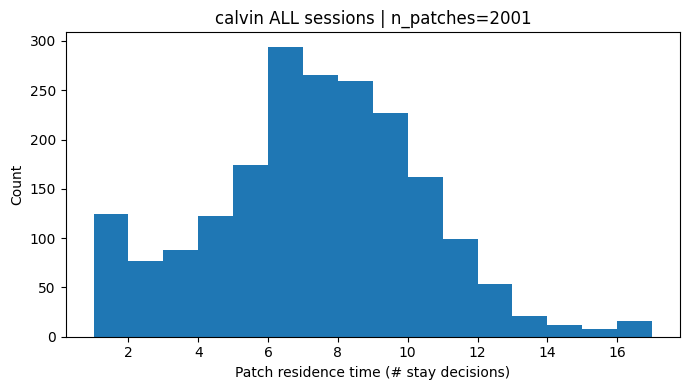

In [46]:
# todas las sesiones juntas
L_all = plot_patch_dist_all_sessions(df, monkey="calvin", bins=16, cutoff_3std=True)

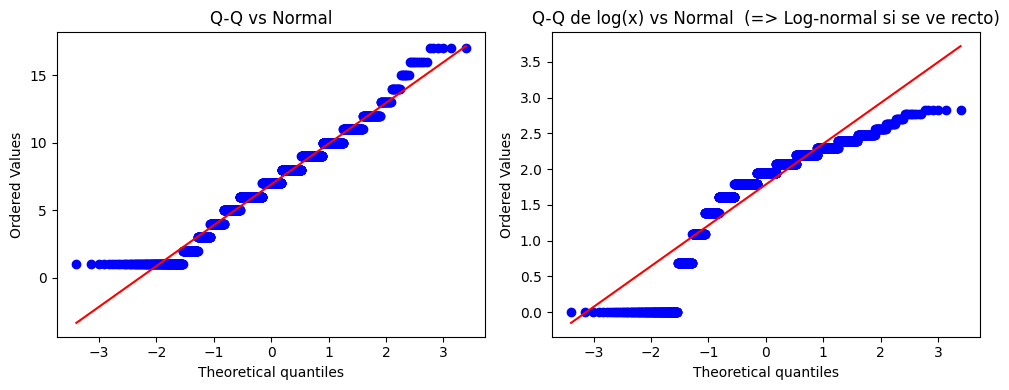

logLik normal: -5073.361851641471
logLik lognormal: -5459.76167509792
AIC normal: 10150.723703282942
AIC lognormal: 10923.52335019584
Shapiro (si N<=5000): ShapiroResult(statistic=np.float64(0.9769775421720897), pvalue=np.float64(1.9867528956778388e-17))


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = L_all.dropna().astype(float).to_numpy()
x = x[x > 0]  # log-normal requiere positivos

# 1) Q-Q plots (lo más útil visualmente)
fig, ax = plt.subplots(1, 2, figsize=(10,4))

stats.probplot(x, dist="norm", plot=ax[0])
ax[0].set_title("Q-Q vs Normal")

stats.probplot(np.log(x), dist="norm", plot=ax[1])
ax[1].set_title("Q-Q de log(x) vs Normal  (=> Log-normal si se ve recto)")

plt.tight_layout()
plt.show()

# 2) Ajuste por máxima verosimilitud + comparación simple
# Normal
mu, sd = stats.norm.fit(x)
ll_norm = np.sum(stats.norm.logpdf(x, loc=mu, scale=sd))

# Log-normal (SciPy usa shape=sigma, scale=exp(mu); forzamos loc=0)
sigma, loc, scale = stats.lognorm.fit(x, floc=0)
ll_logn = np.sum(stats.lognorm.logpdf(x, sigma, loc=0, scale=scale))

print("logLik normal:", ll_norm)
print("logLik lognormal:", ll_logn)
print("AIC normal:", 2*2 - 2*ll_norm)
print("AIC lognormal:", 2*2 - 2*ll_logn)

# 3) Test rápido (normalidad) — ojo: con N grande casi siempre rechaza
print("Shapiro (si N<=5000):", stats.shapiro(x[:5000]))

n_patches: 2025 mean: 7.062716049382716 median: 7.0


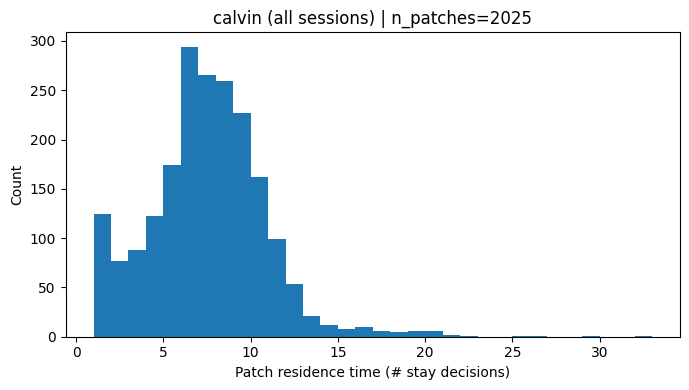

In [48]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

def _error_mask(df):
    # works with your json_normalize output: columns like trialErrors_error1, trialErrors_trialErrors_raw, etc.
    err_cols = [c for c in df.columns if c.startswith("trialErrors_")]
    if not err_cols:
        return pd.Series(False, index=df.index)
    return df[err_cols].notna().any(axis=1)

def patch_lengths_reference(df, monkey, *, exclude_errors=False):
    """
    Returns patch residence times for ONE monkey across ALL sessions,
    computed per (date, session) so patches never cross sessions.

    Reference-code match:
      length = # stays before leave
      keep only length >= 1
      ignore incomplete final patch (session ends without a leave)
    """
    d = df.query("monkey == @monkey").copy()
    d = d.sort_values(["date", "session", "trial"]).reset_index(drop=True)

    if exclude_errors:
        d = d[~_error_mask(d)].copy()

    out = []

    for (_date, _session), g in d.groupby(["date", "session"], dropna=False):
        g = g.sort_values("trial").reset_index(drop=True)

        choice = g["choiceMade"].astype(str).to_numpy()
        leave_idx = np.flatnonzero(choice == "leave")
        if len(leave_idx) == 0:
            continue

        starts = np.r_[0, leave_idx[:-1] + 1]
        lengths = leave_idx - starts  # <= this is "#stays before leave" (paper-style)
        lengths = lengths[lengths >= 1]  # xPatch: goodPatches length>=1

        out.append(lengths.astype(int))

    return np.concatenate(out) if out else np.array([], dtype=int)

# ---- usage ----
monkey_name = "calvin"

x = patch_lengths_reference(df, monkey_name, exclude_errors=False)  # try True if you want
print("n_patches:", len(x), "mean:", x.mean() if len(x) else None, "median:", np.median(x) if len(x) else None)

plt.figure(figsize=(7,4))
plt.hist(x, bins=range(int(x.min()), int(x.max()) + 2) if len(x) else 10)
plt.xlabel("Patch residence time (# stay decisions)")
plt.ylabel("Count")
plt.title(f"{monkey_name} (all sessions) | n_patches={len(x)}")
plt.tight_layout()
plt.show()

In [49]:
import numpy as np
import pandas as pd
from scipy import stats

def summarize_counts(x):
    x = np.asarray(x, dtype=float)
    s = {
        "N": len(x),
        "min": float(x.min()),
        "max": float(x.max()),
        "mean": float(x.mean()),
        "median": float(np.median(x)),
        "var": float(x.var(ddof=1)),
        "sd": float(x.std(ddof=1)),
    }
    s["cv"] = s["sd"] / s["mean"]
    s["fano"] = s["var"] / s["mean"]  # Var/Mean: Poisson~1, NegBin>1
    s["skew"] = float(stats.skew(x, bias=False))
    s["kurtosis_excess"] = float(stats.kurtosis(x, bias=False))
    return pd.Series(s)

def aic_bic(ll, k, n):
    return (2*k - 2*ll, k*np.log(n) - 2*ll)

def fit_compare_discrete_patchlength(x):
    x = np.asarray(x, dtype=int)
    x = x[x >= 1]
    if len(x) < 5:
        raise ValueError("Need more data")

    rows = []
    n = len(x)

    # Geometric on x (support 1,2,3,...). MLE p = 1/mean(x)
    p = 1 / x.mean()
    ll = np.sum(stats.geom.logpmf(x, p))
    rows.append(("geometric(x>=1)", 1, ll, *aic_bic(ll, 1, n), {"p": float(p)}))

    # Poisson on y=x-1 (support 0,1,2,...)
    y = x - 1
    lam = y.mean()
    ll = np.sum(stats.poisson.logpmf(y, mu=lam))
    rows.append(("poisson(y=x-1)", 1, ll, *aic_bic(ll, 1, n), {"lambda": float(lam)}))

    # NegBin on y=x-1 using method-of-moments (works when var>mean)
    m, v = y.mean(), y.var(ddof=1)
    if v > m:
        r = m**2 / (v - m)      # size
        p_nb = r / (r + m)      # prob
        ll = np.sum(stats.nbinom.logpmf(y, n=r, p=p_nb))
        rows.append(("negbin(y=x-1) MOM", 2, ll, *aic_bic(ll, 2, n), {"r": float(r), "p": float(p_nb)}))

    # Log-normal (continuous approximation) on x (positive)
    sigma, loc, scale = stats.lognorm.fit(x.astype(float), floc=0)
    ll = np.sum(stats.lognorm.logpdf(x.astype(float), s=sigma, loc=0, scale=scale))
    rows.append(("lognormal(x) (cont approx)", 2, ll, *aic_bic(ll, 2, n), {"sigma": float(sigma), "scale": float(scale)}))

    table = pd.DataFrame(rows, columns=["model","k","logLik","AIC","BIC","params"]).sort_values("AIC")
    return table

metrics = summarize_counts(x)
display(metrics)

fit_table = fit_compare_discrete_patchlength(x)
display(fit_table)

N                  2025.000000
min                   1.000000
max                  32.000000
mean                  7.062716
median                7.000000
var                  11.645768
sd                    3.412590
cv                    0.483184
fano                  1.648908
skew                  0.896276
kurtosis_excess       3.836137
dtype: float64

,model,k,logLik,AIC,BIC,params
2,negbin(y=x-1) MOM,2,-5338.136821,10680.273642,10691.500292,"{'r': 6.583589795008511, 'p': 0.5205939090843991}"
3,lognormal(x) (cont approx),2,-5590.199021,11184.398042,11195.624692,"{'sigma': 0.6321333216147128, 'scale': 6.05151..."
1,poisson(y=x-1),1,-5613.291664,11228.583329,11234.196654,{'lambda': 6.062716049382716}
0,geometric(x>=1),1,-5832.881736,11667.763473,11673.376798,{'p': 0.14158858900853027}
